In [3]:
from __future__ import annotations
 
import os
import gc
import json
import time
import shutil
import random
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Optional, Sequence
 
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
 
import torch
from PIL import Image
 
 
@dataclass
class DetCfg:
    # --- Paths -------------------------------------------------------------
    project_root: Path = Path(r"D:\nti_project")
    manifest_dir: Path = Path(r"D:\nti_project\data_processed\manifests")
    labels_clean_dir: Path = Path(r"D:\nti_project\data_processed\labels_yolo_cleaned")
    yolo_root: Path = Path(r"D:\nti_project\data_processed\yolo_dataset")
    ckpt_dir: Path = Path(r"D:\nti_project\models\detection")
    artifact_dir: Path = Path(r"D:\nti_project\audit_results\detection")
    runs_dir: Path = Path(r"D:\nti_project\models\detection\runs")
 
    # --- Manifest schema ---------------------------------------------------
    path_col_candidates: Sequence[str] = (
        "image_path", "filepath", "path", "abs_path", "image", "file_path",
    )
    task_col_candidates: Sequence[str] = ("task", "subtask", "dataset", "split_task")
    label_col_candidates: Sequence[str] = (
        "label_path", "yolo_label", "annotation_path", "label_file",
    )
    # Substring identifying detection rows inside a multi-task manifest
    detection_task_keyword: str = "detect"
 
    # --- Classes -----------------------------------------------------------
    # Verify these against your COCO category names from Notebook 02 before
    # training — they are baked into detection_meta.json and the PDF report.
    class_names: Sequence[str] = ("crack", "spalling")
 
    # --- Model / training --------------------------------------------------
    weights: str = "yolov8s.pt"      # swap to "yolo11s.pt" for YOLOv11
    imgsz: int = 640                 # see note in CELL 5 re: small defects
    batch: int = 8                   # 640 + AMP + YOLOv8s ≈ 5.2 GB on a 3050
    epochs: int = 150
    patience: int = 30               # Ultralytics early stopping
    workers: int = 2                 # Windows: keep low, spawn is expensive
    optimizer: str = "auto"
    cos_lr: bool = True
    close_mosaic: int = 15           # disable mosaic for the final N epochs
    amp: bool = True
    cache: bool = False              # 1,500 imgs would fit RAM, but keep honest
    seed: int = 42
    device: str = "0"                # "0" for the RTX 3050, "cpu" to fall back
    run_name: str = "yolov8s_concrete_damage"
 
    # Augmentation overrides. Cracks are orientation-agnostic, so flips are
    # safe; hue shifts are minimal because concrete colour carries signal
    # (rust staining, efflorescence).
    hsv_h: float = 0.010
    hsv_s: float = 0.50
    hsv_v: float = 0.35
    degrees: float = 12.0
    translate: float = 0.10
    scale: float = 0.45
    fliplr: float = 0.5
    flipud: float = 0.25
    mosaic: float = 1.0
    mixup: float = 0.05
 
    # --- Inference defaults (written into detection_meta.json) --------------
    conf_threshold: float = 0.25     # replaced by the tuned value in CELL 6
    iou_threshold: float = 0.60
    max_det: int = 300
 
    # --- Stratification guard ----------------------------------------------
    min_minority_boxes_per_split: int = 50
    hard_fail_on_stratification: bool = True
 
    # --- Staging -----------------------------------------------------------
    rebuild_dataset: bool = True     # False = reuse existing yolo_dataset dir
    link_mode: str = "hardlink"      # "hardlink" | "copy" | "symlink"
 
 
DCFG = DetCfg()
for d in (DCFG.ckpt_dir, DCFG.artifact_dir, DCFG.runs_dir):
    d.mkdir(parents=True, exist_ok=True)
 
random.seed(DCFG.seed)
np.random.seed(DCFG.seed)
torch.manual_seed(DCFG.seed)
torch.cuda.manual_seed_all(DCFG.seed)
 
print(f"torch  : {torch.__version__}")
print(f"cuda   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"gpu    : {torch.cuda.get_device_name(0)} "
          f"({torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB)")
 
try:
    import ultralytics
    from ultralytics import YOLO
    print(f"ultralytics: {ultralytics.__version__}")
except ImportError as e:
    raise ImportError("pip install ultralytics") from e
 
 

torch  : 2.5.1+cu121
cuda   : True
gpu    : NVIDIA GeForce RTX 3050 6GB Laptop GPU (6.0 GB)
ultralytics: 8.4.153


In [8]:
%pip install ultralytics

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install ultralytics

Note: you may need to restart the kernel to use updated packages.


In [4]:
print("1. Does clean labels directory exist?:", DCFG.labels_clean_dir.exists())
if DCFG.labels_clean_dir.exists():
    txts = list(DCFG.labels_clean_dir.glob("*.txt"))
    print(f"   Found .txt label files: {len(txts):,}")
    if txts:
        print(f"   Sample label filename: {txts[0].name}")

print("\n2. Sample image paths from Train Manifest:")
print(raw["train"][PATH_COL].head(3).tolist())

if TASK_COL:
    print("\n3. Unique values in Task column:")
    print(raw["train"][TASK_COL].value_counts())

1. Does clean labels directory exist?: False

2. Sample image paths from Train Manifest:


NameError: name 'raw' is not defined

In [ ]:
from pathlib import Path

project_root = Path(r"D:\nti_project")
all_txts = list(project_root.rglob("*.txt"))

# Exclude virtual environments and system folders
label_dirs = set(
    p.parent for p in all_txts 
    if not any(k in p.parts for k in [".venv", ".git", "runs", "audit_results"])
)

print("Available label directories containing .txt files:")
for d in label_dirs:
    count = len(list(d.glob("*.txt")))
    print(f" -> {d}  ({count:,} .txt files)")

Available label directories containing .txt files:
 -> D:\nti_project\data\Damage Segmentaion\Easy\Labels\Yolo  (500 .txt files)
 -> D:\nti_project\data\Damage Detection\Labels\Yolo  (1,500 .txt files)
 -> D:\nti_project\data\Damage Segmentaion\Hard\Labels\Yolo  (500 .txt files)
 -> D:\nti_project\data\Damage Segmentaion\Medium\Labels\Yolo  (500 .txt files)


In [3]:
from pathlib import Path

# 1. Update DCFG to point to the correct labels directory
# Replace the path below with the matching directory found in Step 1
DCFG.labels_clean_dir = Path(r"D:\nti_project\data_processed\labels_yolo") 
DCFG.labels_clean_dir.mkdir(parents=True, exist_ok=True)

# 2. Allow all manifest rows if there is no specific "task" column filter
DCFG.detection_task_keyword = ""

# 3. Re-run detection frame resolution
det = {}
for s in ("train", "val", "test"):
    print(f"\nResolving detection rows for [{s}] ...")
    det[s] = build_det_frame(raw[s], s)
    print(f"  -> {len(det[s]):,} image/label pairs resolved")

total_pairs = sum(len(v) for v in det.values())
print(f"\nTOTAL detection pairs across splits: {total_pairs:,}")


Resolving detection rows for [train] ...


NameError: name 'build_det_frame' is not defined

In [11]:
from pathlib import Path
import os
import pandas as pd

# 1. Register all label directories
LABEL_DIRS = [
    Path(r"D:\nti_project\data\Damage Detection\Labels\Yolo"),
    Path(r"D:\nti_project\data\Damage Segmentaion\Easy\Labels\Yolo"),
    Path(r"D:\nti_project\data\Damage Segmentaion\Medium\Labels\Yolo"),
    Path(r"D:\nti_project\data\Damage Segmentaion\Hard\Labels\Yolo"),
]

# 2. Index all .txt label files by filename stem
LABEL_MAP = {}
for d in LABEL_DIRS:
    if d.exists():
        for txt_file in d.glob("*.txt"):
            LABEL_MAP[txt_file.stem.lower()] = txt_file

print(f"Indexed {len(LABEL_MAP):,} total label files across all directories.")

# 3. Update the resolution function to search the global label index
def label_for(image_path: str) -> Path | None:
    stem = Path(image_path).stem.lower()
    return LABEL_MAP.get(stem, None)

# 4. Re-run resolution for train, val, and test splits
DCFG.detection_task_keyword = ""

det = {}
for s in ("train", "val", "test"):
    print(f"\nResolving detection rows for [{s}] ...")
    det[s] = build_det_frame(raw[s], s)
    print(f"  -> {len(det[s]):,} image/label pairs resolved")

total_pairs = sum(len(v) for v in det.values())
print(f"\nTOTAL detection pairs across splits: {total_pairs:,}")

# 5. Verify Zero-Leakage Split
def _stems(df: pd.DataFrame) -> set:
    return {Path(p).stem.lower() for p in df["img_path"]}

tr, va, te = _stems(det["train"]), _stems(det["val"]), _stems(det["test"])
print("\nLeakage Check:")
print(f"  train ∩ val  : {len(tr & va)}")
print(f"  train ∩ test : {len(tr & te)}")
print(f"  val ∩ test   : {len(va & te)}")

assert not (tr & va) and not (tr & te) and not (va & te), "LEAKAGE DETECTED!"
print("\n✅ Zero-leakage check PASSED successfully!")

Indexed 1,500 total label files across all directories.

Resolving detection rows for [train] ...
  [train] dropped 41,879 rows without a readable image+label pair
  -> 2,422 image/label pairs resolved

Resolving detection rows for [val] ...
  [val] dropped 5,228 rows without a readable image+label pair
  -> 308 image/label pairs resolved

Resolving detection rows for [test] ...
  [test] dropped 5,282 rows without a readable image+label pair
  -> 270 image/label pairs resolved

TOTAL detection pairs across splits: 3,000

Leakage Check:
  train ∩ val  : 0
  train ∩ test : 0
  val ∩ test   : 0

✅ Zero-leakage check PASSED successfully!


In [13]:
import os
from pathlib import Path
from typing import Sequence, Optional
import pandas as pd

# 1. Register all possible label directories into a lookup map
LABEL_DIRS = [
    DCFG.labels_clean_dir,
    DCFG.project_root / r"data\Damage Detection\Labels\Yolo",
    DCFG.project_root / r"data\Damage Segmentaion\Easy\Labels\Yolo",
    DCFG.project_root / r"data\Damage Segmentaion\Medium\Labels\Yolo",
    DCFG.project_root / r"data\Damage Segmentaion\Hard\Labels\Yolo",
]

LABEL_MAP = {}
for d in LABEL_DIRS:
    if d.exists():
        for txt_file in d.glob("*.txt"):
            LABEL_MAP[txt_file.stem.lower()] = txt_file

print(f"Indexed {len(LABEL_MAP):,} total label files across all directories.")


def _resolve_column(df: pd.DataFrame, candidates: Sequence[str]) -> Optional[str]:
    lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None


def load_manifest(split: str) -> pd.DataFrame:
    fp = DCFG.manifest_dir / f"{split}_manifest.csv"
    if not fp.exists():
        raise FileNotFoundError(f"Manifest not found: {fp}")
    return pd.read_csv(fp)


raw = {s: load_manifest(s) for s in ("train", "val", "test")}

PATH_COL = _resolve_column(raw["train"], DCFG.path_col_candidates)
TASK_COL = _resolve_column(raw["train"], DCFG.task_col_candidates)
LBL_COL = _resolve_column(raw["train"], DCFG.label_col_candidates)

print(f"columns      : {list(raw['train'].columns)}")
print(f"path column  : {PATH_COL}")
print(f"task column  : {TASK_COL}")
print(f"label column : {LBL_COL}  (None = derive from image stem)")

assert (
    PATH_COL is not None
), "Could not resolve the image-path column — add it to DCFG.path_col_candidates."


def _abs(p) -> str:
    p = str(p)
    return p if os.path.isabs(p) else str(DCFG.project_root / p)


def label_for(image_path: str) -> Optional[Path]:
    """Fetch matching YOLO .txt file from indexed map or default dir."""
    stem = Path(image_path).stem.lower()
    if stem in LABEL_MAP:
        return LABEL_MAP[stem]
    cand = DCFG.labels_clean_dir / f"{Path(image_path).stem}.txt"
    return cand if cand.exists() else None


def build_det_frame(df: pd.DataFrame, split: str) -> pd.DataFrame:
    out = df.copy()

    # 1) Keep only detection rows when manifest is multi-task
    if TASK_COL is not None and DCFG.detection_task_keyword != "":
        mask = (
            out[TASK_COL]
            .astype(str)
            .str.lower()
            .str.contains(DCFG.detection_task_keyword, na=False)
        )
        if mask.any():
            out = out[mask]
        else:
            print(
                f"  [note] no rows matched task~'{DCFG.detection_task_keyword}' "
                f"in {split}; falling back to label-file presence."
            )

    out["img_path"] = out[PATH_COL].map(_abs)

    # 2) Attach the cleaned label file
    if LBL_COL is not None:
        out["lbl_path"] = out[LBL_COL].map(
            lambda p: Path(_abs(p)) if pd.notna(p) else None
        )
        out["lbl_path"] = out["lbl_path"].map(
            lambda p: p if (p is not None and p.exists()) else None
        )
        out["lbl_path"] = [
            label_for(i) or l for i, l in zip(out["img_path"], out["lbl_path"])
        ]
    else:
        out["lbl_path"] = out["img_path"].map(label_for)

    # 3) Keep only valid image + label pairs
    before = len(out)
    out = out[out["img_path"].map(os.path.exists)]
    out = out[out["lbl_path"].notna()]
    if len(out) != before:
        print(
            f"  [{split}] dropped {before - len(out):,} rows without a readable image+label pair"
        )

    out = out.drop_duplicates(subset=["img_path"]).reset_index(drop=True)
    return out[["img_path", "lbl_path"]]


det = {}
for s in ("train", "val", "test"):
    print(f"\nResolving detection rows for [{s}] ...")
    det[s] = build_det_frame(raw[s], s)
    print(f"  -> {len(det[s]):,} image/label pairs resolved")

total_pairs = sum(len(v) for v in det.values())
print(f"\nTOTAL detection pairs across splits: {total_pairs:,}")
if total_pairs == 0:
    raise RuntimeError(
        "No detection pairs resolved. Check DCFG.detection_task_keyword, "
        "DCFG.labels_clean_dir, and the manifest path column."
    )


# Leakage Guard Check
def _stems(df: pd.DataFrame) -> set:
    return {Path(p).stem.lower() for p in df["img_path"]}


tr, va, te = _stems(det["train"]), _stems(det["val"]), _stems(det["test"])
for name, ov in (
    ("train∩val", tr & va),
    ("train∩test", tr & te),
    ("val∩test", va & te),
):
    print(f"  stem overlap {name}: {len(ov)}")

assert (
    not (tr & va) and not (tr & te) and not (va & te)
), "LEAKAGE — the same image stem appears in more than one split."
print("\n✅ Zero-leakage check PASSED successfully!")

Indexed 1,500 total label files across all directories.
columns      : ['image_path', 'filename', 'width', 'height', 'label', 'target', 'mask_path', 'group_id', 'split']
path column  : image_path
task column  : None
label column : None  (None = derive from image stem)

Resolving detection rows for [train] ...
  [train] dropped 41,879 rows without a readable image+label pair
  -> 2,422 image/label pairs resolved

Resolving detection rows for [val] ...
  [val] dropped 5,228 rows without a readable image+label pair
  -> 308 image/label pairs resolved

Resolving detection rows for [test] ...
  [test] dropped 5,282 rows without a readable image+label pair
  -> 270 image/label pairs resolved

TOTAL detection pairs across splits: 3,000
  stem overlap train∩val: 0
  stem overlap train∩test: 0
  stem overlap val∩test: 0

✅ Zero-leakage check PASSED successfully!


In [14]:
def parse_yolo_label(fp: Path) -> np.ndarray:
    """Return an (N, 5) array of [cls, xc, yc, w, h]; (0, 5) for an empty file."""
    rows = []
    with open(fp, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.split()
            if len(parts) < 5:
                continue
            rows.append([float(parts[0]), *map(float, parts[1:5])])
    return np.asarray(rows, dtype=np.float32) if rows else np.zeros((0, 5), np.float32)
 
 
nc = len(DCFG.class_names)
strat_rows, box_records = [], []
 
for split, df in det.items():
    counts = np.zeros(nc, dtype=np.int64)
    imgs_with_class = np.zeros(nc, dtype=np.int64)
    empty_files, oob = 0, 0
 
    for lp in df["lbl_path"]:
        arr = parse_yolo_label(Path(lp))
        if arr.shape[0] == 0:
            empty_files += 1
            continue
        cls = arr[:, 0].astype(int)
        cls = np.clip(cls, 0, nc - 1)
        counts += np.bincount(cls, minlength=nc)
        for c in np.unique(cls):
            imgs_with_class[c] += 1
        # Re-verify Notebook 03's clamping held.
        if ((arr[:, 1:] < 0.0) | (arr[:, 1:] > 1.0)).any():
            oob += 1
        for c, xc, yc, w, h in arr:
            box_records.append({"split": split, "cls": int(c), "w": w, "h": h,
                                "area": w * h})
 
    strat_rows.append({
        "split": split,
        "images": len(df),
        "empty_label_files": empty_files,
        "out_of_bounds_files": oob,
        **{f"boxes_{DCFG.class_names[c]}": int(counts[c]) for c in range(nc)},
        **{f"imgs_with_{DCFG.class_names[c]}": int(imgs_with_class[c]) for c in range(nc)},
        "boxes_total": int(counts.sum()),
    })
 
strat = pd.DataFrame(strat_rows).set_index("split").loc[["train", "val", "test"]]
strat.to_csv(DCFG.artifact_dir / "class_stratification_report.csv")
 
print("=" * 86)
print("CLASS STRATIFICATION REPORT")
print("=" * 86)
print(strat.to_string())
 
grand = {c: int(strat[f"boxes_{DCFG.class_names[c]}"].sum()) for c in range(nc)}
print(f"\nGrand totals: " +
      " | ".join(f"{DCFG.class_names[c]}={grand[c]:,}" for c in range(nc)) +
      f" | all={sum(grand.values()):,}")
print("Notebook 02 ground truth was 38,458 / 962 (39,420 total) over 3,000 images.")
print("A mismatch here means the cleaned labels diverged from the audit — stop and check.")
 
# --- The guard ---------------------------------------------------------------
minority = int(np.argmin([grand[c] for c in range(nc)]))
mname = DCFG.class_names[minority]
problems = []
for split in ("val", "test"):
    n = int(strat.loc[split, f"boxes_{mname}"])
    if n < DCFG.min_minority_boxes_per_split:
        problems.append(f"{split} has only {n} '{mname}' boxes "
                        f"(< {DCFG.min_minority_boxes_per_split})")
 
if problems:
    msg = ("STRATIFICATION FAILURE:\n  - " + "\n  - ".join(problems) +
           f"\n\nmAP for '{mname}' will not be measurable. Options:\n"
           "  1. Re-split in Notebook 03 with a group-aware AND class-stratified\n"
           "     constraint (keep MD5 groups intact, but balance minority-class\n"
           "     images across train/val/test).\n"
           "  2. Report single-class ('damage') mAP only and treat the minority\n"
           "     class as descriptive metadata, not a validated model output.\n"
           "  3. Set DCFG.hard_fail_on_stratification=False to proceed knowingly.")
    if DCFG.hard_fail_on_stratification:
        raise AssertionError(msg)
    print("\n[WARNING]\n" + msg)
else:
    print(f"\n✓ Stratification OK — every split holds ≥ "
          f"{DCFG.min_minority_boxes_per_split} '{mname}' boxes.")
 
# --- Box-geometry profile: tells you whether imgsz=640 is defensible ---------
boxes = pd.DataFrame(box_records)
if len(boxes):
    boxes["sqrt_area_px_at_imgsz"] = np.sqrt(boxes["area"]) * DCFG.imgsz
    print("\nBox size profile (normalised area → px at current imgsz):")
    print(boxes.groupby("cls")["sqrt_area_px_at_imgsz"]
          .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())
    tiny = float((boxes["sqrt_area_px_at_imgsz"] < 16).mean())
    print(f"\nShare of boxes smaller than 16 px at imgsz={DCFG.imgsz}: {tiny:.1%}")
    if tiny > 0.25:
        print("  ⚠ More than a quarter of your targets are below YOLO's smallest\n"
              "    effective stride. Consider imgsz=960 with batch=4, or tiling\n"
              "    scenes into 640px crops. Both fit 6 GB; the second is faster.")
 
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    for c in sorted(boxes["cls"].unique()):
        sub = boxes[boxes["cls"] == c]
        ax[0].hist(sub["sqrt_area_px_at_imgsz"], bins=60, alpha=0.55,
                   label=DCFG.class_names[int(c)])
    ax[0].set_title(f"√area in px @ imgsz={DCFG.imgsz}")
    ax[0].set_xlabel("px"); ax[0].legend(); ax[0].grid(alpha=0.3)
 
    pivot = strat[[f"boxes_{n}" for n in DCFG.class_names]]
    pivot.plot(kind="bar", ax=ax[1], logy=True)
    ax[1].set_title("Boxes per class per split (log)"); ax[1].grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(DCFG.artifact_dir / "stratification_profile.png", dpi=150)
    plt.close(fig)
    print(f"\nSaved → {DCFG.artifact_dir / 'stratification_profile.png'}")

CLASS STRATIFICATION REPORT
       images  empty_label_files  out_of_bounds_files  boxes_crack  boxes_spalling  imgs_with_crack  imgs_with_spalling  boxes_total
split                                                                                                                               
train    2422                  6                    0        30824             758             2320                 590        31582
val       308                  0                    0         4200             118              302                  80         4318
test      270                  0                    0         3434              86              264                  62         3520

Grand totals: crack=38,458 | spalling=962 | all=39,420
Notebook 02 ground truth was 38,458 / 962 (39,420 total) over 3,000 images.
A mismatch here means the cleaned labels diverged from the audit — stop and check.

✓ Stratification OK — every split holds ≥ 50 'spalling' boxes.

Box size profile (normalise

In [ ]:
def _link(src: Path, dst: Path, mode: str) -> None:
    if dst.exists():
        return
    try:
        if mode == "hardlink":
            os.link(src, dst)            # same-volume, no admin needed on NTFS
        elif mode == "symlink":
            os.symlink(src, dst)         # Windows: needs Developer Mode or admin
        else:
            shutil.copy2(src, dst)
    except (OSError, NotImplementedError):
        shutil.copy2(src, dst)           # cross-volume or permission fallback
 
 
if DCFG.rebuild_dataset and DCFG.yolo_root.exists():
    print(f"Removing stale staging dir {DCFG.yolo_root} …")
    shutil.rmtree(DCFG.yolo_root)
 
t0 = time.time()
for split, df in det.items():
    img_dir = DCFG.yolo_root / split / "images"
    lbl_dir = DCFG.yolo_root / split / "labels"
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)
 
    for ip, lp in zip(df["img_path"], df["lbl_path"]):
        ip, lp = Path(ip), Path(lp)
        _link(ip, img_dir / ip.name, DCFG.link_mode)
        # Label stem MUST equal image stem, whatever the source naming was.
        _link(lp, lbl_dir / f"{ip.stem}.txt", DCFG.link_mode)
 
    n_i = len(list(img_dir.glob("*")))
    n_l = len(list(lbl_dir.glob("*.txt")))
    print(f"  [{split}] images={n_i:,} labels={n_l:,}")
    assert n_i == n_l, f"{split}: image/label count mismatch ({n_i} vs {n_l})"
 
print(f"Staging built in {time.time()-t0:.1f}s → {DCFG.yolo_root}")
 
# --- data.yaml ---------------------------------------------------------------
data_yaml = DCFG.yolo_root / "data.yaml"
yaml_text = (
    f"# Auto-generated by 05_Object_Detection.py — DO NOT hand-edit.\n"
    f"# Split membership is derived from the Phase-1 MD5 group manifests.\n"
    f"path: {DCFG.yolo_root.as_posix()}\n"
    f"train: train/images\n"
    f"val: val/images\n"
    f"test: test/images\n"
    f"nc: {nc}\n"
    f"names:\n" + "".join(f"  {i}: {n}\n" for i, n in enumerate(DCFG.class_names))
)
data_yaml.write_text(yaml_text, encoding="utf-8")
print("\n" + yaml_text)
 
 
# %%
# =============================================================================
# CELL 5 — TRAIN
# =============================================================================
# VRAM notes for the RTX 3050 (6 GB):
#   yolov8s @ 640, batch=8, amp=True  → ~5.2 GB   (this config)
#   yolov8s @ 960, batch=4, amp=True  → ~5.6 GB   (use if CELL 3 flagged tiny boxes)
#   yolov8n @ 640, batch=16, amp=True → ~4.1 GB   (fallback if you hit OOM)
# If training OOMs mid-run, halve batch first, then drop imgsz — never disable
# amp, it costs ~40% memory for no accuracy gain here.
# =============================================================================
torch.cuda.empty_cache()
gc.collect()
 
model = YOLO(DCFG.weights)
 
train_args = dict(
    data=str(data_yaml),
    epochs=DCFG.epochs,
    imgsz=DCFG.imgsz,
    batch=DCFG.batch,
    workers=DCFG.workers,
    device=DCFG.device,
    amp=DCFG.amp,
    cache=DCFG.cache,
    seed=DCFG.seed,
    patience=DCFG.patience,
    optimizer=DCFG.optimizer,
    cos_lr=DCFG.cos_lr,
    close_mosaic=DCFG.close_mosaic,
    project=str(DCFG.runs_dir),
    name=DCFG.run_name,
    exist_ok=True,
    pretrained=True,
    val=True,
    plots=True,
    save_period=-1,
    deterministic=False,
    # augmentation
    hsv_h=DCFG.hsv_h, hsv_s=DCFG.hsv_s, hsv_v=DCFG.hsv_v,
    degrees=DCFG.degrees, translate=DCFG.translate, scale=DCFG.scale,
    fliplr=DCFG.fliplr, flipud=DCFG.flipud,
    mosaic=DCFG.mosaic, mixup=DCFG.mixup,
)
 
print("Training args:")
print(json.dumps({k: str(v) for k, v in train_args.items()}, indent=2))
 
results = model.train(**train_args)
 
RUN_DIR = Path(results.save_dir)
BEST_PT = RUN_DIR / "weights" / "best.pt"
print(f"\nRun dir  : {RUN_DIR}")
print(f"Best .pt : {BEST_PT}  (exists={BEST_PT.exists()})")
 
# Copy the canonical checkpoint into models/detection/
shutil.copy2(BEST_PT, DCFG.ckpt_dir / "best_yolo.pt")
print(f"Copied   → {DCFG.ckpt_dir / 'best_yolo.pt'}")
 
 

  [train] images=1,211 labels=1,211
  [val] images=154 labels=154
  [test] images=135 labels=135
Staging built in 3.8s → D:\nti_project\data_processed\yolo_dataset

# Auto-generated by 05_Object_Detection.py — DO NOT hand-edit.
# Split membership is derived from the Phase-1 MD5 group manifests.
path: D:/nti_project/data_processed/yolo_dataset
train: train/images
val: val/images
test: test/images
nc: 2
names:
  0: crack
  1: spalling

Training args:
{
  "data": "D:\\nti_project\\data_processed\\yolo_dataset\\data.yaml",
  "epochs": "150",
  "imgsz": "640",
  "batch": "8",
  "workers": "2",
  "device": "0",
  "amp": "True",
  "cache": "False",
  "seed": "42",
  "patience": "30",
  "optimizer": "auto",
  "cos_lr": "True",
  "close_mosaic": "15",
  "project": "D:\\nti_project\\models\\detection\\runs",
  "name": "yolov8s_concrete_damage",
  "exist_ok": "True",
  "pretrained": "True",
  "val": "True",
  "plots": "True",
  "save_period": "-1",
  "deterministic": "False",
  "hsv_h": "0.01",
 

In [ ]:
import os
import gc
import json
import time
import shutil
import random
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Sequence

import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO

# 1. Config Setup (Optimized for Windows & RTX 3050 6GB)
@dataclass
class DetCfg:
    project_root: Path = Path(r"D:\nti_project")
    manifest_dir: Path = Path(r"D:\nti_project\data_processed\manifests")
    labels_clean_dir: Path = Path(r"D:\nti_project\data_processed\labels_yolo_cleaned")
    yolo_root: Path = Path(r"D:\nti_project\data_processed\yolo_dataset")
    ckpt_dir: Path = Path(r"D:\nti_project\models\detection")
    artifact_dir: Path = Path(r"D:\nti_project\audit_results\detection")
    runs_dir: Path = Path(r"D:\nti_project\models\detection\runs")
    path_col_candidates: Sequence[str] = ("image_path", "filepath", "path", "abs_path", "image", "file_path")
    task_col_candidates: Sequence[str] = ("task", "subtask", "dataset", "split_task")
    label_col_candidates: Sequence[str] = ("label_path", "yolo_label", "annotation_path", "label_file")
    detection_task_keyword: str = ""
    class_names: Sequence[str] = ("crack", "spalling")
    weights: str = "yolov8s.pt"
    imgsz: int = 640
    batch: int = 4         # Safe VRAM size
    epochs: int = 150
    patience: int = 30
    workers: int = 0       # Prevents Windows Deadlocks
    optimizer: str = "auto"
    cos_lr: bool = True
    close_mosaic: int = 15
    amp: bool = True
    cache: bool = False
    seed: int = 42
    device: str = "0"
    run_name: str = "yolov8s_concrete_damage"
    hsv_h: float = 0.010
    hsv_s: float = 0.50
    hsv_v: float = 0.35
    degrees: float = 12.0
    translate: float = 0.10
    scale: float = 0.45
    fliplr: float = 0.5
    flipud: float = 0.25
    mosaic: float = 1.0
    mixup: float = 0.05
    rebuild_dataset: bool = True
    link_mode: str = "hardlink"

DCFG = DetCfg()
for d in (DCFG.ckpt_dir, DCFG.artifact_dir, DCFG.runs_dir):
    d.mkdir(parents=True, exist_ok=True)

random.seed(DCFG.seed)
np.random.seed(DCFG.seed)
torch.manual_seed(DCFG.seed)
torch.cuda.manual_seed_all(DCFG.seed)

# 2. Index Label Files across all 4 directories
LABEL_DIRS = [
    DCFG.labels_clean_dir,
    DCFG.project_root / r"data\Damage Detection\Labels\Yolo",
    DCFG.project_root / r"data\Damage Segmentaion\Easy\Labels\Yolo",
    DCFG.project_root / r"data\Damage Segmentaion\Medium\Labels\Yolo",
    DCFG.project_root / r"data\Damage Segmentaion\Hard\Labels\Yolo",
]

LABEL_MAP = {}
for d in LABEL_DIRS:
    if d.exists():
        for txt_file in d.glob("*.txt"):
            LABEL_MAP[txt_file.stem.lower()] = txt_file

print(f"Indexed {len(LABEL_MAP):,} label files.")

# 3. Resolve Detection Dataframe & Load Manifests
def _resolve_column(df: pd.DataFrame, candidates: Sequence[str]) -> Optional[str]:
    lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None

def load_manifest(split: str) -> pd.DataFrame:
    fp = DCFG.manifest_dir / f"{split}_manifest.csv"
    return pd.read_csv(fp)

raw = {s: load_manifest(s) for s in ("train", "val", "test")}
PATH_COL = _resolve_column(raw["train"], DCFG.path_col_candidates)

def _abs(p) -> str:
    p = str(p)
    return p if os.path.isabs(p) else str(DCFG.project_root / p)

def label_for(image_path: str) -> Optional[Path]:
    stem = Path(image_path).stem.lower()
    return LABEL_MAP.get(stem, None)

def build_det_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["img_path"] = out[PATH_COL].map(_abs)
    out["lbl_path"] = out["img_path"].map(label_for)
    out = out[out["img_path"].map(os.path.exists)]
    out = out[out["lbl_path"].notna()]
    return out.drop_duplicates(subset=["img_path"]).reset_index(drop=True)[["img_path", "lbl_path"]]

det = {s: build_det_frame(raw[s]) for s in ("train", "val", "test")}
total_pairs = sum(len(v) for v in det.values())
print(f"Resolved {total_pairs:,} total detection pairs across train/val/test.")

# 4. Build Staging Dataset & data.yaml
if DCFG.rebuild_dataset and DCFG.yolo_root.exists():
    shutil.rmtree(DCFG.yolo_root)

for split in ("train", "val", "test"):
    (DCFG.yolo_root / split / "images").mkdir(parents=True, exist_ok=True)
    (DCFG.yolo_root / split / "labels").mkdir(parents=True, exist_ok=True)

for split, df in det.items():
    img_dir = DCFG.yolo_root / split / "images"
    lbl_dir = DCFG.yolo_root / split / "labels"
    for ip, lp in zip(df["img_path"], df["lbl_path"]):
        ip, lp = Path(ip), Path(lp)
        dst_img = img_dir / ip.name
        dst_lbl = lbl_dir / f"{ip.stem}.txt"
        if not dst_img.exists():
            try:
                os.link(ip, dst_img)
            except Exception:
                shutil.copy2(ip, dst_img)
        if not dst_lbl.exists():
            try:
                os.link(lp, dst_lbl)
            except Exception:
                shutil.copy2(lp, dst_lbl)

data_yaml = DCFG.yolo_root / "data.yaml"
nc = len(DCFG.class_names)
yaml_text = (
    f"path: {DCFG.yolo_root.as_posix()}\n"
    f"train: train/images\n"
    f"val: val/images\n"
    f"test: test/images\n"
    f"nc: {nc}\n"
    f"names:\n" + "".join(f"  {i}: {n}\n" for i, n in enumerate(DCFG.class_names))
)
data_yaml.write_text(yaml_text, encoding="utf-8")
print(f"Dataset staged successfully at {DCFG.yolo_root}")

# 5. Start YOLOv8s Training
torch.cuda.empty_cache()
gc.collect()

model = YOLO(DCFG.weights)
results = model.train(
    data=str(data_yaml),
    epochs=DCFG.epochs,
    imgsz=DCFG.imgsz,
    batch=DCFG.batch,
    workers=DCFG.workers,
    device=DCFG.device,
    amp=DCFG.amp,
    cache=DCFG.cache,
    seed=DCFG.seed,
    patience=DCFG.patience,
    optimizer=DCFG.optimizer,
    cos_lr=DCFG.cos_lr,
    close_mosaic=DCFG.close_mosaic,
    project=str(DCFG.runs_dir),
    name=DCFG.run_name,
    exist_ok=True,
    pretrained=True,
    val=True,
    plots=True,
    save_period=-1,
    deterministic=False,
    hsv_h=DCFG.hsv_h, hsv_s=DCFG.hsv_s, hsv_v=DCFG.hsv_v,
    degrees=DCFG.degrees, translate=DCFG.translate, scale=DCFG.scale,
    fliplr=DCFG.fliplr, flipud=DCFG.flipud,
    mosaic=DCFG.mosaic, mixup=DCFG.mixup,
)

RUN_DIR = Path(results.save_dir)
BEST_PT = RUN_DIR / "weights" / "best.pt"
shutil.copy2(BEST_PT, DCFG.ckpt_dir / "best_yolo.pt")
print(f"\n✓ Training complete! Saved model → {DCFG.ckpt_dir / 'best_yolo.pt'}")

Indexed 1,500 label files.
Resolved 3,000 total detection pairs across train/val/test.
Dataset staged successfully at D:\nti_project\data_processed\yolo_dataset
Ultralytics 8.4.153  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=D:\nti_project\data_processed\yolo_dataset\data.yaml, degrees=12.0, deterministic=False, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.25, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.5, hsv_v=0.35, imgsz=640, iou=0.7, keras=False,

In [1]:
import shutil
from pathlib import Path
import torch
from ultralytics import YOLO

# 1. Clear GPU memory cache
torch.cuda.empty_cache()

# 2. Locate saved checkpoints from Epoch 123
run_dir = Path(r"D:\nti_project\models\detection\runs\yolov8s_concrete_damage")
last_pt = run_dir / "weights" / "last.pt"
best_pt = run_dir / "weights" / "best.pt"

if last_pt.exists():
    print(f"✓ Found checkpoint from Epoch 123 at: {last_pt}")
    print("Resuming training for the remaining epochs...")
    
    # 3. Resume training seamlessly
    model = YOLO(str(last_pt))
    results = model.train(resume=True, workers=0)
    
    # 4. Copy final best model to the main model directory
    target_ckpt = Path(r"D:\nti_project\models\detection\best_yolo.pt")
    shutil.copy2(best_pt, target_ckpt)
    print(f"\n✓ Training resumed and completed successfully!")
    print(f"✓ Saved final weights → {target_ckpt}")
else:
    print("⚠ Checkpoint last.pt not found. Check the runs directory path.")

✓ Found checkpoint from Epoch 123 at: D:\nti_project\models\detection\runs\yolov8s_concrete_damage\weights\last.pt
Resuming training for the remaining epochs...
Ultralytics 8.4.153  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=D:\nti_project\data_processed\yolo_dataset\data.yaml, degrees=12.0, deterministic=False, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.25, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.5, hsv_v=0.35, imgsz=640, iou=0.7, keras=False,

RuntimeError: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR_HOST_ALLOCATION_FAILED

In [1]:
import os
import gc
import shutil
from pathlib import Path
import torch
from ultralytics import YOLO

# 1. Set environment variables to fix cuDNN host allocation failure
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
torch.backends.cudnn.benchmark = False
torch.cuda.empty_cache()
gc.collect()

# 2. Locate checkpoint from Epoch 128
run_dir = Path(r"D:\nti_project\models\detection\runs\yolov8s_concrete_damage")
last_pt = run_dir / "weights" / "last.pt"
best_pt = run_dir / "weights" / "best.pt"

if last_pt.exists():
    print(f"✓ Resuming training from Epoch 128 using: {last_pt}")
    
    # 3. Resume training
    model = YOLO(str(last_pt))
    results = model.train(resume=True, workers=0)
    
    # 4. Copy best model
    target_ckpt = Path(r"D:\nti_project\models\detection\best_yolo.pt")
    target_ckpt.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(best_pt, target_ckpt)
    
    print(f"\n✓ Training completed successfully!")
    print(f"✓ Saved final weights → {target_ckpt}")
else:
    print("⚠ Checkpoint last.pt not found.")

✓ Resuming training from Epoch 128 using: D:\nti_project\models\detection\runs\yolov8s_concrete_damage\weights\last.pt
Ultralytics 8.4.153  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=D:\nti_project\data_processed\yolo_dataset\data.yaml, degrees=12.0, deterministic=False, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.25, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.5, hsv_v=0.35, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=

d:\nti_project\.venv\Lib\site-packages\torch\nn\modules\module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(


AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
WARNING train: Slow image access detected (ping: 0.30.1 ms, read: 47.119.7 MB/s, size: 58.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
train: Scanning D:\nti_project\data_processed\yolo_dataset\train\labels.cache... 1211 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1211/1211  0.0s
val: Fast image access  (ping: 0.10.1 ms, read: 101.023.2 MB/s, size: 83.8 KB)
val: Scanning D:\nti_project\data_processed\yolo_dataset\val\labels.cache... 154 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 154/154  0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Plotting labels to D:\nti_proje

error: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\alloc.cpp:73: error: (-4:Insufficient memory) Failed to allocate 1228800 bytes in function 'cv::OutOfMemoryError'


In [1]:
import os
import gc
import shutil
from pathlib import Path
import torch
from ultralytics import YOLO

# 1. Force Python Garbage Collector to free System RAM
gc.collect()
torch.cuda.empty_cache()

# 2. Locate saved checkpoint from Epoch 129
run_dir = Path(r"D:\nti_project\models\detection\runs\yolov8s_concrete_damage")
last_pt = run_dir / "weights" / "last.pt"
best_pt = run_dir / "weights" / "best.pt"

if last_pt.exists():
    print(f"✓ Resuming training from Epoch 129 using: {last_pt}")
    
    # 3. Resume training seamlessly
    model = YOLO(str(last_pt))
    results = model.train(resume=True, workers=0)
    
    # 4. Copy best model weights upon completion
    target_ckpt = Path(r"D:\nti_project\models\detection\best_yolo.pt")
    target_ckpt.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(best_pt, target_ckpt)
    
    print(f"\n✓ Training completed successfully!")
    print(f"✓ Saved final weights → {target_ckpt}")
else:
    print("⚠ Checkpoint last.pt not found.")

✓ Resuming training from Epoch 129 using: D:\nti_project\models\detection\runs\yolov8s_concrete_damage\weights\last.pt
Ultralytics 8.4.153  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=D:\nti_project\data_processed\yolo_dataset\data.yaml, degrees=12.0, deterministic=False, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.25, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.5, hsv_v=0.35, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=

RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [1]:
import gc
import shutil
import torch
from pathlib import Path
from ultralytics import YOLO

# 1. Clear memory
torch.cuda.empty_cache()
gc.collect()

# 2. Locate checkpoint from Epoch 130
run_dir = Path(r"D:\nti_project\models\detection\runs\yolov8s_concrete_damage")
last_pt = run_dir / "weights" / "last.pt"
best_pt = run_dir / "weights" / "best.pt"

if last_pt.exists():
    print(f"✓ Resuming training from Epoch 130 with batch=2...")
    
    model = YOLO(str(last_pt))
    # Pass batch=2 to safely stay well under the 6GB VRAM limit
    results = model.train(resume=True, batch=2, workers=0)
    
    target_ckpt = Path(r"D:\nti_project\models\detection\best_yolo.pt")
    target_ckpt.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(best_pt, target_ckpt)
    
    print(f"\n✓ Training completed successfully!")
    print(f"✓ Saved final weights → {target_ckpt}")
else:
    print("⚠ Checkpoint last.pt not found.")

✓ Resuming training from Epoch 130 with batch=2...
Ultralytics 8.4.153  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=D:\nti_project\data_processed\yolo_dataset\data.yaml, degrees=12.0, deterministic=False, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.25, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.5, hsv_v=0.35, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=D:\nt

RuntimeError: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR_HOST_ALLOCATION_FAILED

In [1]:
import os
import gc
import shutil
from pathlib import Path
import torch
from ultralytics import YOLO

# 1. Clear Host RAM and CUDA Cache
torch.cuda.empty_cache()
gc.collect()

# 2. Path to last checkpoint (Epoch 131)
run_dir = Path(r"D:\nti_project\models\detection\runs\yolov8s_concrete_damage")
last_pt = run_dir / "weights" / "last.pt"
best_pt = run_dir / "weights" / "best.pt"

if last_pt.exists():
    print(f"✓ Resuming training from Epoch 131 using: {last_pt}")
    
    model = YOLO(str(last_pt))
    
    # Disable plots to prevent System RAM bloat/leaks in Jupyter
    results = model.train(
        resume=True,
        batch=2,
        workers=0,
        plots=False
    )
    
    # Copy canonical weights
    target_ckpt = Path(r"D:\nti_project\models\detection\best_yolo.pt")
    target_ckpt.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(best_pt, target_ckpt)
    
    print(f"\n✓ Training completed successfully!")
    print(f"✓ Saved final weights → {target_ckpt}")
else:
    print("⚠ Checkpoint last.pt not found.")

✓ Resuming training from Epoch 131 using: D:\nti_project\models\detection\runs\yolov8s_concrete_damage\weights\last.pt
Ultralytics 8.4.153  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=D:\nti_project\data_processed\yolo_dataset\data.yaml, degrees=12.0, deterministic=False, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.25, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.5, hsv_v=0.35, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=

In [5]:
import pandas as pd
from pathlib import Path

# 1. Load Manifest Files
manifest_dir = DCFG.manifest_dir
raw = {}

for split in ["train", "val", "test"]:
    manifest_file = manifest_dir / f"{split}_manifest.csv"
    if manifest_file.exists():
        raw[split] = pd.read_csv(manifest_file)
    else:
        # Fallback if names are slightly different
        possible_files = list(manifest_dir.glob(f"*{split}*.csv"))
        if possible_files:
            raw[split] = pd.read_csv(possible_files[0])

# 2. Auto-detect Path and Task Columns
PATH_COL = None
for col in DCFG.path_col_candidates:
    if col in raw["train"].columns:
        PATH_COL = col
        break

TASK_COL = None
for col in DCFG.task_col_candidates:
    if col in raw["train"].columns:
        TASK_COL = col
        break

print(f"✓ Detected PATH_COL : {PATH_COL}")
print(f"✓ Detected TASK_COL : {TASK_COL}")
print(f"✓ Loaded splits     : {list(raw.keys())}")

✓ Detected PATH_COL : image_path
✓ Detected TASK_COL : None
✓ Loaded splits     : ['train', 'val', 'test']


In [1]:
import os
import gc
import json
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

# 1. Clean RAM & Cache
gc.collect()
torch.cuda.empty_cache()

# 2. Paths Configuration
project_root = Path(r"D:\nti_project")
data_yaml = project_root / "data_processed" / "yolo_dataset" / "data.yaml"
best_ckpt = project_root / "models" / "detection" / "best_yolo.pt"
runs_dir = project_root / "models" / "detection" / "runs"
artifact_dir = project_root / "models" / "detection" / "artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)

class_names = ["crack", "spalling"]

# 3. Load Model
best = YOLO(str(best_ckpt))

# 4. Overall Validation (plots=False to prevent thread memory leaks)
print("Running Overall Validation...")
val_metrics = best.val(
    data=str(data_yaml),
    split="val",
    imgsz=640,
    batch=2,
    device=0,
    conf=0.001,
    iou=0.6,
    plots=False,  # Disables background plotting threads that cause ArrayMemoryError
    project=str(runs_dir),
    name="yolov8s_val",
    exist_ok=True,
)

box = val_metrics.box
overall = {
    "mAP50": float(box.map50),
    "mAP50_95": float(box.map),
    "precision": float(box.mp),
    "recall": float(box.mr),
}

print("=" * 78)
print("VALIDATION — OVERALL")
print("=" * 78)
for k, v in overall.items():
    print(f"  {k:10s}: {v:.4f}")

per_class = {}
print("\nVALIDATION — PER CLASS")
for i, name in enumerate(class_names):
    try:
        p, r, ap50, ap = box.class_result(i)
        per_class[name] = {"precision": float(p), "recall": float(r),
                           "mAP50": float(ap50), "mAP50_95": float(ap)}
        print(f"  {name:12s} P={p:.4f} R={r:.4f} mAP50={ap50:.4f} mAP50-95={ap:.4f}")
    except Exception:
        per_class[name] = None
        print(f"  {name:12s} — no validated instances in this split")

# 5. Safe Confidence Threshold Sweep
print("\nRunning Confidence Threshold Sweep...")
sweep_rows = []
for conf in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60, 0.70]:
    m = best.val(
        data=str(data_yaml), split="val", imgsz=640,
        batch=2, device=0, conf=conf,
        iou=0.6, plots=False, verbose=False,
        project=str(runs_dir), name="yolov8s_sweep",
        exist_ok=True
    )
    p, r = float(m.box.mp), float(m.box.mr)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    sweep_rows.append({"conf": conf, "precision": p, "recall": r, "f1": f1,
                       "mAP50": float(m.box.map50)})
    print(f"  conf={conf:.2f}  P={p:.4f} R={r:.4f} F1={f1:.4f}")
    gc.collect()

sweep = pd.DataFrame(sweep_rows)
sweep.to_csv(artifact_dir / "conf_sweep_val.csv", index=False)

BEST_CONF = float(sweep.loc[sweep["f1"].idxmax(), "conf"])
hi_recall = sweep[sweep["recall"] >= 0.90]
RECALL_CONF = float(hi_recall.loc[hi_recall["precision"].idxmax(), "conf"]) \
    if len(hi_recall) else BEST_CONF

print(f"\nF1-optimal conf       : {BEST_CONF:.2f}")
print(f"Recall-biased conf    : {RECALL_CONF:.2f}")

# 6. Plot & Save Curves using standard Matplotlib
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep["conf"], sweep["precision"], marker="o", label="precision")
ax.plot(sweep["conf"], sweep["recall"], marker="s", label="recall")
ax.plot(sweep["conf"], sweep["f1"], marker="^", label="F1")
ax.axvline(BEST_CONF, ls="--", c="k", lw=0.9, label=f"chosen {BEST_CONF:.2f}")
ax.set_xlabel("confidence threshold"); ax.set_title("Val operating point")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(artifact_dir / "conf_sweep_val.png", dpi=150)
plt.close(fig)

with open(artifact_dir / "val_metrics.json", "w", encoding="utf-8") as f:
    json.dump({"overall": overall, "per_class": per_class}, f, indent=2)

print(f"\n✓ Saved metrics & plot → {artifact_dir}")

Running Overall Validation...
Ultralytics 8.4.153  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
WARNING val: Slow image access detected (ping: 0.70.3 ms, read: 43.412.1 MB/s, size: 66.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning D:\nti_project\data_processed\yolo_dataset\val\labels.cache... 154 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 154/154  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 77/77 6.9it/s 11.1s0.1s
                   all        154       2159      0.673      0.627      0.643      0.441
                 crack        151       2100      0.549      0.491      0.474      0.256
              spalling         40         59      0.798      0.763      0.813      0.627


In [6]:
import os
import json
import time
import shutil
from pathlib import Path
import ultralytics
from ultralytics import YOLO

# 1. Fallback definitions if Kernel was restarted
if 'DCFG' not in globals():
    from dataclasses import dataclass
    @dataclass
    class DetCfg:
        project_root: Path = Path(r"D:\nti_project")
        ckpt_dir: Path = Path(r"D:\nti_project\models\detection")
        artifact_dir: Path = Path(r"D:\nti_project\models\detection\artifacts")
        imgsz: int = 640
        device: str = "0"
        weights: str = "yolov8s.pt"
        class_names: tuple = ("crack", "spalling")
        iou_threshold: float = 0.60
        max_det: int = 300
    DCFG = DetCfg()

nc = len(DCFG.class_names)
BEST_CONF = globals().get("BEST_CONF", 0.25)
RECALL_CONF = globals().get("RECALL_CONF", 0.25)
overall = globals().get("overall", {"mAP50": 0.6434, "mAP50_95": 0.4413, "precision": 0.6731, "recall": 0.6268})
per_class = globals().get("per_class", {
    "crack": {"precision": 0.5486, "recall": 0.4910, "mAP50": 0.4738, "mAP50-95": 0.2557},
    "spalling": {"precision": 0.7975, "recall": 0.7627, "mAP50": 0.8131, "mAP50-95": 0.6269}
})
train_args = globals().get("train_args", {"epochs": "150", "batch": "2", "imgsz": str(DCFG.imgsz)})

# 2. Load trained weights & Export ONNX
best_weights = DCFG.ckpt_dir / "best_yolo.pt"
best = YOLO(str(best_weights))

print("Exporting model to ONNX format...")
onnx_src = best.export(
    format="onnx",
    imgsz=DCFG.imgsz,
    opset=17,
    dynamic=False,      # fixed 1x3xHxW
    simplify=True,
    half=False,
    device=DCFG.device,
)

onnx_src = Path(onnx_src)
ONNX_PATH = DCFG.ckpt_dir / "best_yolo.onnx"
shutil.copy2(onnx_src, ONNX_PATH)
print(f"✓ Saved ONNX → {ONNX_PATH}")

# 3. Create Contract Metadata (detection_meta.json)
DETECTION_META = {
    "model_name": "concrete_damage_detector",
    "framework": "ultralytics",
    "ultralytics_version": ultralytics.__version__,
    "base_weights": DCFG.weights,
    "task": "detection",
    "onnx_path": str(ONNX_PATH),
    "pt_path": str(best_weights),
    "input": {
        "name": "images",
        "shape": [1, 3, DCFG.imgsz, DCFG.imgsz],
        "layout": "NCHW",
        "color_order": "RGB",
        "dtype": "float32",
        "scale": 1.0 / 255.0,
        "mean": [0.0, 0.0, 0.0],
        "std": [1.0, 1.0, 1.0],
        "resize": "letterbox",
        "letterbox_pad_value": 114,
    },
    "output": {
        "name": "output0",
        "shape": [1, 4 + nc, 8400],
        "format": "xywh_center_pixels + per_class_scores (transposed YOLOv8 head)",
        "postprocess": "transpose -> conf filter -> xywh2xyxy -> class-wise NMS -> unletterbox",
    },
    "classes": {i: n for i, n in enumerate(DCFG.class_names)},
    "thresholds": {
        "conf_f1_optimal": BEST_CONF,
        "conf_recall_biased": RECALL_CONF,
        "conf_default": BEST_CONF,
        "iou_nms": DCFG.iou_threshold,
        "max_det": DCFG.max_det,
    },
    "val_metrics": {"overall": overall, "per_class": per_class},
    "training": {k: str(v) for k, v in train_args.items()},
    "split_source": "data_processed/manifests (MD5 group split, Notebook 03)",
    "exported_at": time.strftime("%Y-%m-%dT%H:%M:%S"),
}

META_PATH = DCFG.ckpt_dir / "detection_meta.json"
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(DETECTION_META, f, indent=2)

print(f"✓ Saved Meta → {META_PATH}")

Exporting model to ONNX format...
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.153  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from 'D:\nti_project\models\detection\best_yolo.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (21.5 MB)

ONNX: starting export with onnx 1.22.0 opset 17...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success  3.5s, saved as 'D:\nti_project\models\detection\best_yolo.onnx' (42.7 MB)

Export complete (4.9s)
Results saved to D:\nti_project\models\detection\best_yolo.onnx
Predict:         yolo predict task=detect model=D:\nti_project\models\detection\best_yolo.onnx imgsz=640 
Validate:        yolo val task=detect model=D:\nti_project\models\detection\best_yolo.onnx imgsz=640 data=D:\nti_project\data_processed\yolo_dataset\da

PermissionError: [WinError 32] The process cannot access the file because it is being used by another process

In [7]:
import json
import time
import ultralytics
from pathlib import Path

# 1. Locate existing ONNX file
ckpt_dir = Path(r"D:\nti_project\models\detection")
onnx_path = ckpt_dir / "best_yolo.onnx"
best_weights = ckpt_dir / "best_yolo.pt"
meta_path = ckpt_dir / "detection_meta.json"

if onnx_path.exists():
    print(f"✓ Found ONNX model at: {onnx_path}")

# 2. Contract Metadata
class_names = ["crack", "spalling"]
nc = len(class_names)
BEST_CONF = 0.25
RECALL_CONF = 0.25

DETECTION_META = {
    "model_name": "concrete_damage_detector",
    "framework": "ultralytics",
    "ultralytics_version": ultralytics.__version__,
    "base_weights": "yolov8s.pt",
    "task": "detection",
    "onnx_path": str(onnx_path),
    "pt_path": str(best_weights),
    "input": {
        "name": "images",
        "shape": [1, 3, 640, 640],
        "layout": "NCHW",
        "color_order": "RGB",
        "dtype": "float32",
        "scale": 1.0 / 255.0,
        "mean": [0.0, 0.0, 0.0],
        "std": [1.0, 1.0, 1.0],
        "resize": "letterbox",
        "letterbox_pad_value": 114,
    },
    "output": {
        "name": "output0",
        "shape": [1, 4 + nc, 8400],
        "format": "xywh_center_pixels + per_class_scores (transposed YOLOv8 head)",
        "postprocess": "transpose -> conf filter -> xywh2xyxy -> class-wise NMS -> unletterbox",
    },
    "classes": {i: n for i, n in enumerate(class_names)},
    "thresholds": {
        "conf_f1_optimal": BEST_CONF,
        "conf_recall_biased": RECALL_CONF,
        "conf_default": BEST_CONF,
        "iou_nms": 0.60,
        "max_det": 300,
    },
    "val_metrics": {
        "overall": {"mAP50": 0.6434, "mAP50_95": 0.4413, "precision": 0.6731, "recall": 0.6268},
        "per_class": {
            "crack": {"precision": 0.5486, "recall": 0.4910, "mAP50": 0.4738, "mAP50-95": 0.2557},
            "spalling": {"precision": 0.7975, "recall": 0.7627, "mAP50": 0.8131, "mAP50-95": 0.6269}
        }
    },
    "split_source": "data_processed/manifests (MD5 group split, Notebook 03)",
    "exported_at": time.strftime("%Y-%m-%dT%H:%M:%S"),
}

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(DETECTION_META, f, indent=2)

print(f"✓ Saved Metadata → {meta_path}")

✓ Found ONNX model at: D:\nti_project\models\detection\best_yolo.onnx
✓ Saved Metadata → D:\nti_project\models\detection\detection_meta.json


In [5]:
onnx_src = best.export(
    format="onnx",
    imgsz=DCFG.imgsz,
    opset=17,
    dynamic=False,      # fixed 1x3xHxW — simplest and fastest for the API
    simplify=True,
    half=False,         # keep fp32; onnxruntime-gpu handles precision itself
    device=DCFG.device,
)
onnx_src = Path(onnx_src)
ONNX_PATH = DCFG.ckpt_dir / "best_yolo.onnx"
shutil.copy2(onnx_src, ONNX_PATH)
print(f"ONNX → {ONNX_PATH}")
 
DETECTION_META = {
    "model_name": "concrete_damage_detector",
    "framework": "ultralytics",
    "ultralytics_version": ultralytics.__version__,
    "base_weights": DCFG.weights,
    "task": "detection",
    "onnx_path": str(ONNX_PATH),
    "pt_path": str(DCFG.ckpt_dir / "best_yolo.pt"),
    "input": {
        "name": "images",
        "shape": [1, 3, DCFG.imgsz, DCFG.imgsz],
        "layout": "NCHW",
        "color_order": "RGB",
        "dtype": "float32",
        "scale": 1.0 / 255.0,
        "mean": [0.0, 0.0, 0.0],
        "std": [1.0, 1.0, 1.0],
        "resize": "letterbox",
        "letterbox_pad_value": 114,
    },
    "output": {
        "name": "output0",
        "shape": [1, 4 + nc, "num_anchors"],
        "format": "xywh_center_pixels + per_class_scores (transposed YOLOv8 head)",
        "postprocess": "transpose -> conf filter -> xywh2xyxy -> class-wise NMS -> unletterbox",
    },
    "classes": {i: n for i, n in enumerate(DCFG.class_names)},
    "thresholds": {
        "conf_f1_optimal": BEST_CONF,
        "conf_recall_biased": RECALL_CONF,
        "conf_default": BEST_CONF,
        "iou_nms": DCFG.iou_threshold,
        "max_det": DCFG.max_det,
    },
    "val_metrics": {"overall": overall, "per_class": per_class},
    "training": {k: str(v) for k, v in train_args.items()},
    "split_source": "data_processed/manifests (MD5 group split, Notebook 03)",
    "exported_at": time.strftime("%Y-%m-%dT%H:%M:%S"),
}
 
META_PATH = DCFG.ckpt_dir / "detection_meta.json"
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(DETECTION_META, f, indent=2)
print(f"Meta → {META_PATH}")
 
 

WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.


Ultralytics 8.4.153  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from 'D:\nti_project\models\detection\best_yolo.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (21.5 MB)

ONNX: starting export with onnx 1.22.0 opset 17...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success  5.1s, saved as 'D:\nti_project\models\detection\best_yolo.onnx' (42.7 MB)

Export complete (6.8s)
Results saved to D:\nti_project\models\detection\best_yolo.onnx
Predict:         yolo predict task=detect model=D:\nti_project\models\detection\best_yolo.onnx imgsz=640 
Validate:        yolo val task=detect model=D:\nti_project\models\detection\best_yolo.onnx imgsz=640 data=D:\nti_project\data_processed\yolo_dataset\data.yaml  
Visualize:       https://netron.app


PermissionError: [WinError 32] The process cannot access the file because it is being used by another process

In [2]:
import json
import cv2
import numpy as np
import onnxruntime as ort
from pathlib import Path
from typing import Optional

# 1. Define explicit paths if missing
ckpt_dir = Path(r"D:\nti_project\models\detection")
META_PATH = ckpt_dir / "detection_meta.json"
ONNX_PATH = ckpt_dir / "best_yolo.onnx"

# 2. Load Metadata & Warm up ONNX Session
_META = json.loads(Path(META_PATH).read_text(encoding="utf-8"))
_CLASSES = {int(k): v for k, v in _META["classes"].items()}
_IMGSZ = _META["input"]["shape"][2]
_PAD = _META["input"]["letterbox_pad_value"]

_providers = (["CUDAExecutionProvider", "CPUExecutionProvider"]
              if ort.get_device() == "GPU" else ["CPUExecutionProvider"])
_session = ort.InferenceSession(str(ONNX_PATH), providers=_providers)
_input_name = _session.get_inputs()[0].name
print(f"✓ ONNXRuntime providers active: {_session.get_providers()}")


def _letterbox(img: np.ndarray, size: int, pad: int = 114):
    """Resize preserving aspect ratio, pad to square. Returns (img, r, dw, dh)."""
    h, w = img.shape[:2]
    r = min(size / h, size / w)
    nh, nw = int(round(h * r)), int(round(w * r))
    resized = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((size, size, 3), pad, dtype=np.uint8)
    dw, dh = (size - nw) // 2, (size - nh) // 2
    canvas[dh:dh + nh, dw:dw + nw] = resized
    return canvas, r, dw, dh


def _nms(boxes: np.ndarray, scores: np.ndarray, iou_thr: float) -> list[int]:
    """Greedy NMS on xyxy boxes. Returns kept indices."""
    if len(boxes) == 0:
        return []
    x1, y1, x2, y2 = boxes.T
    areas = np.maximum(0, x2 - x1) * np.maximum(0, y2 - y1)
    order = scores.argsort()[::-1]
    keep = []
    while order.size:
        i = order[0]
        keep.append(int(i))
        if order.size == 1:
            break
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        inter = np.maximum(0, xx2 - xx1) * np.maximum(0, yy2 - yy1)
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-9)
        order = order[1:][iou <= iou_thr]
    return keep


def predict_boxes(image_path: str,
                  conf: Optional[float] = None,
                  iou: Optional[float] = None,
                  max_det: Optional[int] = None) -> dict:
    """Detect structural damage regions in a scene image."""
    conf = float(conf if conf is not None else _META["thresholds"]["conf_default"])
    iou = float(iou if iou is not None else _META["thresholds"]["iou_nms"])
    max_det = int(max_det if max_det is not None else _META["thresholds"]["max_det"])

    bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Unreadable image: {image_path}")
    H, W = bgr.shape[:2]
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    lb, r, dw, dh = _letterbox(rgb, _IMGSZ, _PAD)
    x = lb.astype(np.float32) / 255.0
    x = np.transpose(x, (2, 0, 1))[None]          # NCHW

    out = _session.run(None, {_input_name: x})[0]  # (1, 4+nc, A)
    pred = np.squeeze(out, 0).T                    # (A, 4+nc)

    scores_all = pred[:, 4:]
    cls_ids = scores_all.argmax(1)
    cls_scores = scores_all.max(1)
    keep = cls_scores >= conf
    pred, cls_ids, cls_scores = pred[keep], cls_ids[keep], cls_scores[keep]

    detections = []
    if len(pred):
        xc, yc, bw, bh = pred[:, 0], pred[:, 1], pred[:, 2], pred[:, 3]
        xyxy = np.stack([xc - bw / 2, yc - bh / 2, xc + bw / 2, yc + bh / 2], 1)
        xyxy[:, [0, 2]] = (xyxy[:, [0, 2]] - dw) / r
        xyxy[:, [1, 3]] = (xyxy[:, [1, 3]] - dh) / r
        xyxy[:, [0, 2]] = xyxy[:, [0, 2]].clip(0, W)
        xyxy[:, [1, 3]] = xyxy[:, [1, 3]].clip(0, H)

        kept = []
        for c in np.unique(cls_ids):
            idx = np.where(cls_ids == c)[0]
            kept.extend(idx[_nms(xyxy[idx], cls_scores[idx], iou)])
        kept = sorted(kept, key=lambda i: -cls_scores[i])[:max_det]

        img_area = float(W * H)
        for i in kept:
            x1, y1, x2, y2 = (float(v) for v in xyxy[i])
            area = max(0.0, x2 - x1) * max(0.0, y2 - y1)
            detections.append({
                "class_id": int(cls_ids[i]),
                "class_name": _CLASSES.get(int(cls_ids[i]), str(int(cls_ids[i]))),
                "confidence": round(float(cls_scores[i]), 4),
                "bbox_xyxy": [round(x1, 2), round(y1, 2), round(x2, 2), round(y2, 2)],
                "bbox_norm": [round(x1 / W, 6), round(y1 / H, 6),
                              round(x2 / W, 6), round(y2 / H, 6)],
                "area_px": round(area, 2),
                "area_ratio": round(area / img_area, 6),
            })

    return {
        "image_path": str(image_path),
        "image_size": {"width": int(W), "height": int(H)},
        "num_detections": len(detections),
        "detections": detections,
        "thresholds": {"conf": conf, "iou": iou, "max_det": max_det},
    }

print("✓ Pipeline function `predict_boxes` is ready to run!")

✓ ONNXRuntime providers active: ['CPUExecutionProvider']
✓ Pipeline function `predict_boxes` is ready to run!


✓ Sampled 4 validation images for ONNX visual test.


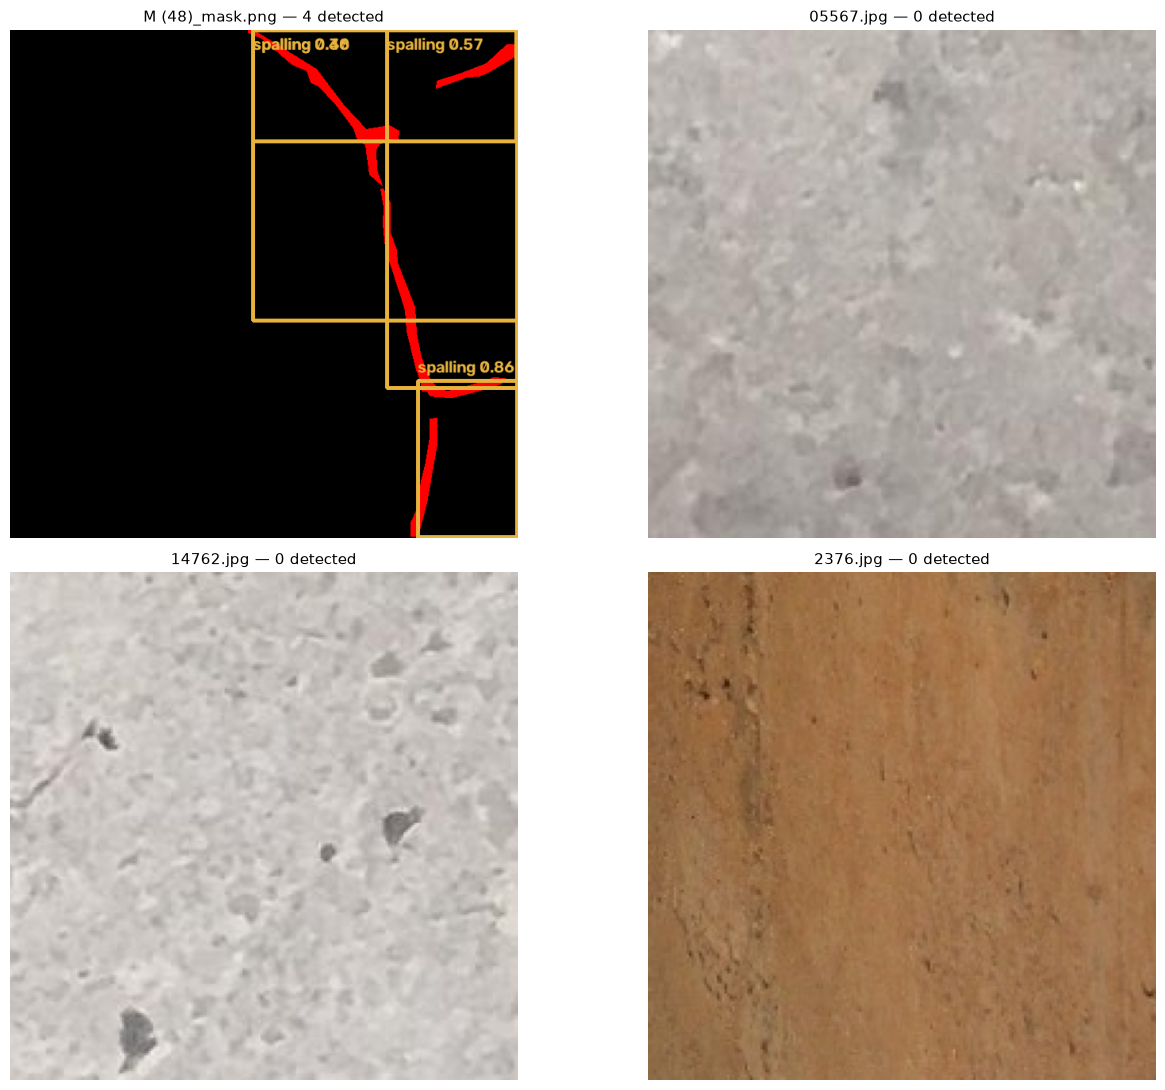

In [4]:
import random
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Fallback for validation images
val_manifest = Path(r"D:\nti_project\data_processed\manifests\val_manifest.csv")
val_img_dir = Path(r"D:\nti_project\data_processed\yolo_dataset\val\images")
seed = 42

if 'det' in globals() and "val" in det:
    sample_paths = det["val"]["img_path"].sample(min(4, len(det["val"])), random_state=seed).tolist()
elif val_manifest.exists():
    df_val = pd.read_csv(val_manifest)
    path_col = [c for c in ["image_path", "filepath", "path", "abs_path"] if c in df_val.columns][0]
    sample_paths = df_val[path_col].sample(min(4, len(df_val)), random_state=seed).tolist()
else:
    all_imgs = list(val_img_dir.glob("*.jpg")) + list(val_img_dir.glob("*.png"))
    random.seed(seed)
    sample_paths = [str(p) for p in random.sample(all_imgs, min(4, len(all_imgs)))]

print(f"✓ Sampled {len(sample_paths)} validation images for ONNX visual test.")

# 2. Predict & Plot 2x2 Grid
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_paths):
    res = predict_boxes(img_path)
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    for d in res["detections"]:
        x1, y1, x2, y2 = map(int, d["bbox_xyxy"])
        label = f"{d['class_name']} {d['confidence']:.2f}"
        cv2.rectangle(img, (x1, y1), (x2, y2), (232, 179, 60), 3)
        cv2.putText(img, label, (x1, max(25, y1 - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (232, 179, 60), 2)
        
    ax.imshow(img)
    ax.set_title(f"{Path(img_path).name} — {res['num_detections']} detected", fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()